In [7]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from Utils.TrainUtils import get_device, build_dataloaders, train_model

from Models.FraudModel import TransformerFraudModel, LastTokenMLP

from Utils.NormalizationUtils import fit_feature_normalizer, apply_feature_normalizer

In [ ]:
# Skip if the directory already exists

stats = fit_feature_normalizer(
    processed_dir="data/processed_fraud",
    output_stats_path="data/processed_fraud/normalization_stats.json",
)

apply_feature_normalizer(
    source_processed_dir="data/processed_fraud",
    target_processed_dir="data/processed_fraud_normalized",
    stats_path="data/processed_fraud/normalization_stats.json",
)

In [31]:
TRANSFORMER_RUN_NAME = "Transformer_baseline"
MLP_RUN_NAME = "MLP_baseline"

BATCH_SIZE = 128
LR = 1e-3
NUM_EPOCHS = 10
METRIC_THRESHOLD = 0.5
DROPOUT= 0.1

D_MODEL = 64
USE_LATENT = False
USE_ERROR = True
USE_AE = False
AE_PATH = "checkpoints/ae_clean.pt"

# Transformer params
SEQ_LEN = 8
N_HEAD = 4
NUM_LAYERS = 3
DIM_FEED_FORWARD = 128


In [32]:
device = get_device()
print(device)

train_loader, val_loader, test_loader = build_dataloaders(
    processed_dir="data/processed_fraud_normalized",
    seq_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

feature_dim = train_loader.dataset.feature_dim
print("Feature dim: ", feature_dim)

cuda
Feature dim:  111


In [33]:
transformer_model = TransformerFraudModel(
    feature_dim=feature_dim,
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEED_FORWARD,
    dropout=DROPOUT,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
    include_ae_gates=False,
)

c:\Users\mengt\Documents\DeepLearning\DL_project\Models\FraudModel.py:204: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sequence_encoder = nn.TransformerEncoder(


In [35]:
mlp_model = LastTokenMLP(
    feature_dim=feature_dim,
    hidden_dim=D_MODEL,
    dropout=DROPOUT,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
    include_ae_gates=False,
)

In [36]:
SELECTED_MODEL = mlp_model

extra_checkpoint_info = {
    "model_class": SELECTED_MODEL.__class__.__name__,
    "feature_dim": feature_dim,
    "seq_len": SEQ_LEN,
    "d_model": D_MODEL if isinstance(SELECTED_MODEL, TransformerFraudModel) else None,
    "nhead": N_HEAD if isinstance(SELECTED_MODEL, TransformerFraudModel) else None,
    "num_layers": NUM_LAYERS if isinstance(SELECTED_MODEL, TransformerFraudModel) else None,
    "dim_feedforward": DIM_FEED_FORWARD if isinstance(SELECTED_MODEL, TransformerFraudModel) else None,
    "dropout": DROPOUT,
    "anomaly_checkpoint_path": AE_PATH if USE_AE else None,
    "freeze_anomaly_encoder": True if USE_AE else None,
    "include_ae_latent": USE_LATENT if USE_AE else None,
    "include_ae_recon_error": USE_ERROR if USE_AE else None,
    "include_ae_gates": False if USE_AE else None,
}

In [37]:
print(type(SELECTED_MODEL))

RUN_NAME = TRANSFORMER_RUN_NAME if isinstance(SELECTED_MODEL, TransformerFraudModel) else MLP_RUN_NAME

summary = train_model(
    model=SELECTED_MODEL,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4,
    checkpoint_dir=f"checkpoints/{RUN_NAME}",
    monitor="val_f2",
    monitor_mode="max",
    use_pos_weight=True,
    max_grad_norm=1.0,
    early_stopping_patience=5,
    extra_checkpoint_info=extra_checkpoint_info,
    metric_threshold=METRIC_THRESHOLD
)

<class 'Models.FraudModel.LastTokenMLP'>
[info] Using pos_weight=27.4009

Epoch 1/10
train_loss=0.9523  val_loss=0.9395
train_pr_auc=0.3823  val_pr_auc=0.3576
train_roc_auc=0.8358  val_roc_auc=0.8236
train_f1=0.2069  val_f1=0.1628
train_f2=0.3567  val_f2=0.3042
train_recall=0.6897  val_recall=0.7223
train_acc=0.8139  val_acc=0.7687
lr=0.001000  epoch_time=15.08s
[checkpoint] Saved new best model -> checkpoints\MLP_baseline\best.pt

Epoch 2/10
train_loss=0.8897  val_loss=0.9158
train_pr_auc=0.4427  val_pr_auc=0.3891
train_roc_auc=0.8603  val_roc_auc=0.8329
train_f1=0.2388  val_f1=0.1760
train_f2=0.3973  val_f2=0.3225
train_recall=0.7125  val_recall=0.7239
train_acc=0.8401  val_acc=0.7889
lr=0.001000  epoch_time=15.09s
[checkpoint] Saved new best model -> checkpoints\MLP_baseline\best.pt

Epoch 3/10
train_loss=0.8594  val_loss=0.9059
train_pr_auc=0.4663  val_pr_auc=0.3989
train_roc_auc=0.8708  val_roc_auc=0.8390
train_f1=0.2531  val_f1=0.2061
train_f2=0.4151  val_f2=0.3547
train_recall=0

<Figure size 1000x500 with 0 Axes>

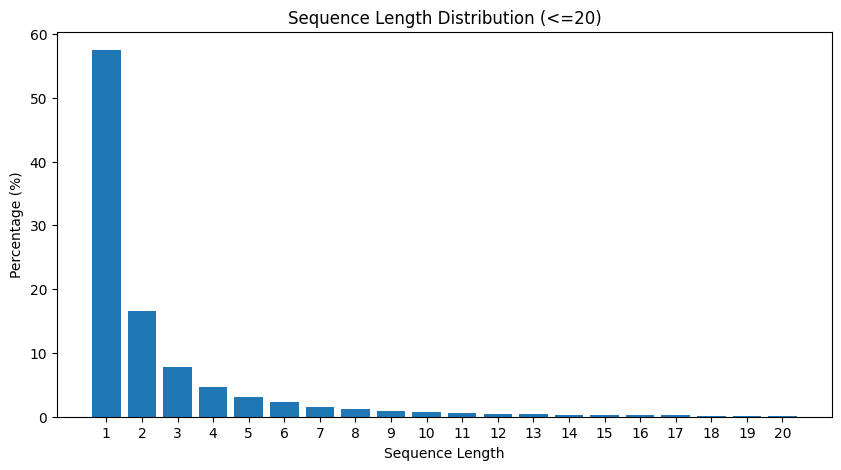

Length 1: 125222
Length 2: 36053
Length 3: 16925
Length 4: 10021
Length 5: 6764
Length 6: 4896
Length 7: 3457
Length 8: 2584
Length 9: 2031
Length 10: 1556
Length 11: 1220
Length 12: 964
Length 13: 871
Length 14: 716
Length 15: 559
Length 16: 505
Length 17: 422
Length 18: 345
Length 19: 290
Length 20: 275
Length 21: 250
Length 22: 209
Length 23: 176
Length 24: 137
Length 25: 141
Length 26: 122
Length 27: 102
Length 28: 80
Length 29: 80
Length 30: 65
Length 31: 69
Length 32: 52
Length 33: 53
Length 34: 47
Length 35: 40
Length 36: 35
Length 37: 40
Length 38: 36
Length 39: 17
Length 40: 28
Length 41: 25
Length 42: 28
Length 43: 16
Length 44: 18
Length 45: 17
Length 46: 18
Length 47: 13
Length 48: 17
Length 49: 19
Length 50: 13
Length 51: 7
Length 52: 10
Length 53: 15
Length 54: 7
Length 55: 8
Length 56: 8
Length 57: 8
Length 58: 10
Length 59: 4
Length 60: 5
Length 61: 5
Length 62: 6
Length 63: 4
Length 64: 5
Length 65: 4
Length 66: 8
Length 67: 3
Length 68: 3
Length 69: 3
Length 70: 4
Len

In [45]:
import matplotlib.pyplot as plt

sequence_length_dist = {}
for l in test_loader.dataset.seq_lengths:
    if not int(l) in sequence_length_dist:
        sequence_length_dist[int(l)] = 1
    else:
        sequence_length_dist[int(l)] += 1

lengths = sorted(sequence_length_dist.keys())
counts = [sequence_length_dist[l] for l in lengths]

total = sum(sequence_length_dist.values())
percentages = [count / total * 100 for count in counts]

plt.figure(figsize=(10, 5))

# only show lengths up to 20
max_len = 20
filtered_lengths = [l for l in lengths if l <= max_len]
filtered_counts = [sequence_length_dist[l] for l in filtered_lengths]

plt.figure(figsize=(10, 5))

# only show lengths up to 20
max_len = 20
filtered_lengths = [l for l in lengths if l <= max_len]
filtered_counts = [sequence_length_dist[l] for l in filtered_lengths]

total = sum(sequence_length_dist.values())
filtered_percent = [c / total * 100 for c in filtered_counts]

plt.bar(filtered_lengths, filtered_percent)

plt.xlabel("Sequence Length")
plt.ylabel("Percentage (%)")
plt.title("Sequence Length Distribution (<=20)")

plt.xticks(filtered_lengths)
plt.show()

for l in sorted(sequence_length_dist):
    print(f"Length {l}: {sequence_length_dist[l]}")


In [49]:
import inspect
import torch

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score,
    fbeta_score,
)

def compute_metrics_from_logits(y_true, logits, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int64)
    logits = np.asarray(logits, dtype=np.float32)

    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= threshold).astype(np.int64)

    metrics = {}

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, probs))
    except Exception:
        metrics["roc_auc"] = float("nan")

    try:
        metrics["pr_auc"] = float(average_precision_score(y_true, probs))
    except Exception:
        metrics["pr_auc"] = float("nan")

    metrics["accuracy"] = float(accuracy_score(y_true, preds))

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        preds,
        average="binary",
        zero_division=0,
    )

    metrics["precision"] = float(precision)
    metrics["recall"] = float(recall)
    metrics["f1"] = float(f1)
    metrics["f2"] = float(
        fbeta_score(y_true, preds, beta=2.0, average="binary", zero_division=0)
    )
    metrics["n"] = int(len(y_true))
    metrics["fraud_rate"] = float(y_true.mean())

    return metrics

def build_model_from_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    extra = ckpt.get("extra", {})

    model_class = extra.get("model_class")
    if model_class is None:
        raise ValueError(f"No model_class found in checkpoint extra for {checkpoint_path}")

    feature_dim = extra["feature_dim"]
    dropout = extra.get("dropout", 0.1)

    if model_class == "TransformerFraudModel":
        candidate_kwargs = {
            "feature_dim": feature_dim,
            "seq_len": extra.get("seq_len", 8),
            "d_model": extra.get("d_model", 64),
            "nhead": extra.get("nhead", 4),
            "num_layers": extra.get("num_layers", 3),
            "dim_feedforward": extra.get("dim_feedforward", 128),
            "dropout": dropout,
            "anomaly_checkpoint_path": extra.get("anomaly_checkpoint_path"),
            "freeze_anomaly_encoder": extra.get("freeze_anomaly_encoder", True),
            "include_ae_latent": extra.get("include_ae_latent", True),
            "include_ae_recon_error": extra.get("include_ae_recon_error", True),
            "include_ae_gates": extra.get("include_ae_gates", False),
        }
        cls = TransformerFraudModel

    elif model_class == "LastTokenMLP":
        candidate_kwargs = {
            "feature_dim": feature_dim,
            "hidden_dim": 64,
            "dropout": dropout,
            "anomaly_checkpoint_path": extra.get("anomaly_checkpoint_path"),
            "freeze_anomaly_encoder": extra.get("freeze_anomaly_encoder", True),
            "include_ae_latent": extra.get("include_ae_latent", True),
            "include_ae_recon_error": extra.get("include_ae_recon_error", True),
            "include_ae_gates": extra.get("include_ae_gates", False),
        }
        cls = LastTokenMLP

    else:
        raise ValueError(f"Unsupported model_class: {model_class}")

    # only pass kwargs the current constructor actually supports
    sig = inspect.signature(cls.__init__)
    filtered_kwargs = {k: v for k, v in candidate_kwargs.items() if k in sig.parameters}

    model = cls(**filtered_kwargs).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model, ckpt, extra

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_logits = []
    all_labels = []
    all_seq_lens = []

    cursor = 0
    seq_lengths = loader.dataset.seq_lengths

    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        y = batch["y"].cpu().numpy()

        logits = model(x, attention_mask).detach().cpu().numpy()

        batch_size = len(y)
        batch_seq_lens = seq_lengths[cursor:cursor + batch_size]
        cursor += batch_size

        all_logits.append(logits)
        all_labels.append(y)
        all_seq_lens.extend([int(s) for s in batch_seq_lens])

    all_logits = np.concatenate(all_logits)
    all_labels = np.concatenate(all_labels)
    all_seq_lens = np.asarray(all_seq_lens, dtype=np.int64)

    return {
        "logits": all_logits,
        "labels": all_labels,
        "seq_lens": all_seq_lens,
    }

def evaluate_prediction_dict(pred_dict, threshold=0.5):
    return compute_metrics_from_logits(
        y_true=pred_dict["labels"],
        logits=pred_dict["logits"],
        threshold=threshold,
    )


def evaluate_by_exact_length(pred_dict, threshold=0.5, min_count=50):
    labels = pred_dict["labels"]
    logits = pred_dict["logits"]
    seq_lens = pred_dict["seq_lens"]

    results = {}

    for L in sorted(np.unique(seq_lens)):
        mask = seq_lens == L
        n = int(mask.sum())
        if n < min_count:
            continue

        results[int(L)] = compute_metrics_from_logits(
            y_true=labels[mask],
            logits=logits[mask],
            threshold=threshold,
        )

    return results


def evaluate_by_buckets(pred_dict, buckets, threshold=0.5):
    """
    buckets example:
    {
        "len=1": lambda s: s == 1,
        "len=2": lambda s: s == 2,
        "len=3-4": lambda s: (s >= 3) & (s <= 4),
        "len=5-8": lambda s: (s >= 5) & (s <= 8),
        "len>=9": lambda s: s >= 9,
    }
    """
    labels = pred_dict["labels"]
    logits = pred_dict["logits"]
    seq_lens = pred_dict["seq_lens"]

    results = {}

    for name, fn in buckets.items():
        mask = fn(seq_lens)
        if mask.sum() == 0:
            continue

        results[name] = compute_metrics_from_logits(
            y_true=labels[mask],
            logits=logits[mask],
            threshold=threshold,
        )

    return results

def print_metrics(title, metrics):
    print(f"\n{title}")
    for k in ["n", "fraud_rate", "pr_auc", "roc_auc", "f2", "f1", "precision", "recall", "accuracy"]:
        if k in metrics:
            print(f"{k:>10s}: {metrics[k]:.4f}" if isinstance(metrics[k], float) else f"{k:>10s}: {metrics[k]}")

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5

transformer_ckpt_path = "checkpoints/Transformer_AE_error/best.pt"
mlp_ckpt_path = "checkpoints/MLP_baseline/best.pt"

transformer_model, transformer_ckpt, transformer_extra = build_model_from_checkpoint(
    transformer_ckpt_path, device
)

mlp_model, mlp_ckpt, mlp_extra = build_model_from_checkpoint(
    mlp_ckpt_path, device
)

print("Loaded transformer:", transformer_extra.get("model_class"), transformer_ckpt_path)
print("Loaded MLP:", mlp_extra.get("model_class"), mlp_ckpt_path)

transformer_preds = collect_predictions(transformer_model, test_loader, device)
mlp_preds = collect_predictions(mlp_model, test_loader, device)

transformer_overall = evaluate_prediction_dict(transformer_preds, threshold=THRESHOLD)
mlp_overall = evaluate_prediction_dict(mlp_preds, threshold=THRESHOLD)

print_metrics("Transformer overall", transformer_overall)
print_metrics("MLP overall", mlp_overall)

c:\Users\mengt\Documents\DeepLearning\DL_project\Models\FraudModel.py:204: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sequence_encoder = nn.TransformerEncoder(


Loaded transformer: TransformerFraudModel checkpoints/Transformer_AE_error/best.pt
Loaded MLP: LastTokenMLP checkpoints/MLP_baseline/best.pt

Transformer overall
         n: 58779
fraud_rate: 0.0372
    pr_auc: 0.4704
   roc_auc: 0.8573
        f2: 0.4870
        f1: 0.3734
 precision: 0.2689
    recall: 0.6110
  accuracy: 0.9238

MLP overall
         n: 58779
fraud_rate: 0.0372
    pr_auc: 0.4515
   roc_auc: 0.8591
        f2: 0.4702
        f1: 0.3351
 precision: 0.2266
    recall: 0.6430
  accuracy: 0.9051


In [51]:
length_buckets = {
    "len=1": lambda s: s == 1,
    "len=2": lambda s: s == 2,
    "len=3-4": lambda s: (s >= 3) & (s <= 4),
    "len=5-8": lambda s: (s >= 5) & (s <= 8),
    "len>=9": lambda s: s >= 9,
}

transformer_bucket_metrics = evaluate_by_buckets(
    transformer_preds, length_buckets, threshold=THRESHOLD
)

mlp_bucket_metrics = evaluate_by_buckets(
    mlp_preds, length_buckets, threshold=THRESHOLD
)

for bucket_name in length_buckets:
    if bucket_name in transformer_bucket_metrics:
        print_metrics(f"Transformer - {bucket_name}", transformer_bucket_metrics[bucket_name])
    if bucket_name in mlp_bucket_metrics:
        print_metrics(f"MLP - {bucket_name}", mlp_bucket_metrics[bucket_name])


Transformer - len=1
         n: 33684
fraud_rate: 0.0370
    pr_auc: 0.4964
   roc_auc: 0.8752
        f2: 0.5061
        f1: 0.3877
 precision: 0.2789
    recall: 0.6356
  accuracy: 0.9257

MLP - len=1
         n: 33684
fraud_rate: 0.0370
    pr_auc: 0.4753
   roc_auc: 0.8778
        f2: 0.4860
        f1: 0.3464
 precision: 0.2342
    recall: 0.6645
  accuracy: 0.9072

Transformer - len=2
         n: 9689
fraud_rate: 0.0377
    pr_auc: 0.4433
   roc_auc: 0.8305
        f2: 0.4667
        f1: 0.3528
 precision: 0.2509
    recall: 0.5945
  accuracy: 0.9178

MLP - len=2
         n: 9689
fraud_rate: 0.0377
    pr_auc: 0.4275
   roc_auc: 0.8355
        f2: 0.4481
        f1: 0.3147
 precision: 0.2103
    recall: 0.6247
  accuracy: 0.8975

Transformer - len=3-4
         n: 7321
fraud_rate: 0.0380
    pr_auc: 0.4580
   roc_auc: 0.8440
        f2: 0.4675
        f1: 0.3626
 precision: 0.2639
    recall: 0.5791
  accuracy: 0.9227

MLP - len=3-4
         n: 7321
fraud_rate: 0.0380
    pr_auc:

In [52]:
transformer_exact = evaluate_by_exact_length(transformer_preds, threshold=THRESHOLD, min_count=100)
mlp_exact = evaluate_by_exact_length(mlp_preds, threshold=THRESHOLD, min_count=100)

print("\nExact-length comparison (min_count=100)")
for L in sorted(set(transformer_exact.keys()) | set(mlp_exact.keys())):
    print(f"\nLength {L}")
    if L in transformer_exact:
        print(f"  Transformer: pr_auc={transformer_exact[L]['pr_auc']:.4f}, "
              f"f2={transformer_exact[L]['f2']:.4f}, "
              f"recall={transformer_exact[L]['recall']:.4f}, "
              f"n={transformer_exact[L]['n']}")
    if L in mlp_exact:
        print(f"  MLP        : pr_auc={mlp_exact[L]['pr_auc']:.4f}, "
              f"f2={mlp_exact[L]['f2']:.4f}, "
              f"recall={mlp_exact[L]['recall']:.4f}, "
              f"n={mlp_exact[L]['n']}")


Exact-length comparison (min_count=100)

Length 1
  Transformer: pr_auc=0.4964, f2=0.5061, recall=0.6356, n=33684
  MLP        : pr_auc=0.4753, f2=0.4860, recall=0.6645, n=33684

Length 2
  Transformer: pr_auc=0.4433, f2=0.4667, recall=0.5945, n=9689
  MLP        : pr_auc=0.4275, f2=0.4481, recall=0.6247, n=9689

Length 3
  Transformer: pr_auc=0.4577, f2=0.4511, recall=0.5614, n=4528
  MLP        : pr_auc=0.4421, f2=0.4177, recall=0.5731, n=4528

Length 4
  Transformer: pr_auc=0.4554, f2=0.4939, recall=0.6075, n=2793
  MLP        : pr_auc=0.4211, f2=0.4712, recall=0.6262, n=2793

Length 5
  Transformer: pr_auc=0.3698, f2=0.4598, recall=0.6275, n=1849
  MLP        : pr_auc=0.2961, f2=0.4101, recall=0.6078, n=1849

Length 6
  Transformer: pr_auc=0.4928, f2=0.4938, recall=0.6038, n=1345
  MLP        : pr_auc=0.5114, f2=0.5286, recall=0.6981, n=1345

Length 7
  Transformer: pr_auc=0.5090, f2=0.4978, recall=0.5750, n=955
  MLP        : pr_auc=0.4558, f2=0.4864, recall=0.6250, n=955

Length

Best Transformer: {'threshold': np.float64(0.5700000000000001), 'precision': 0.322763598865687, 'recall': 0.5729977116704805, 'f1': 0.4129287598944591, 'f2': 0.49607734368808937}
Best MLP: {'threshold': np.float64(0.59), 'precision': 0.27768090671316475, 'recall': 0.5830663615560641, 'f1': 0.3761996161228407, 'f2': 0.47794117647058826}
Best ensemble: {'threshold': np.float64(0.61), 'precision': 0.35823529411764704, 'recall': 0.5574370709382152, 'f1': 0.43616830796777084, 'f2': 0.5016474464579901}


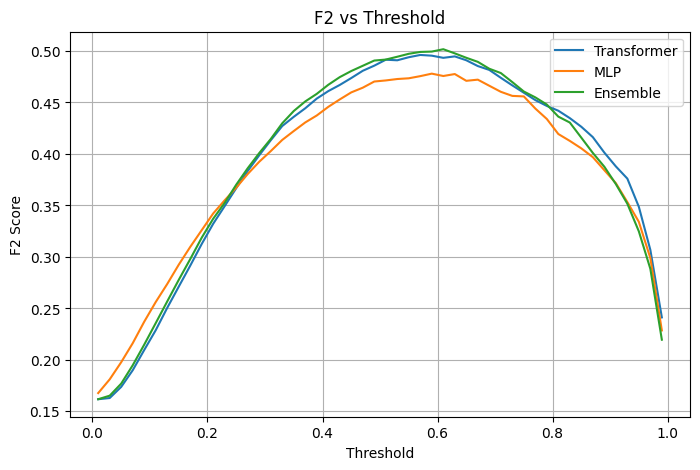

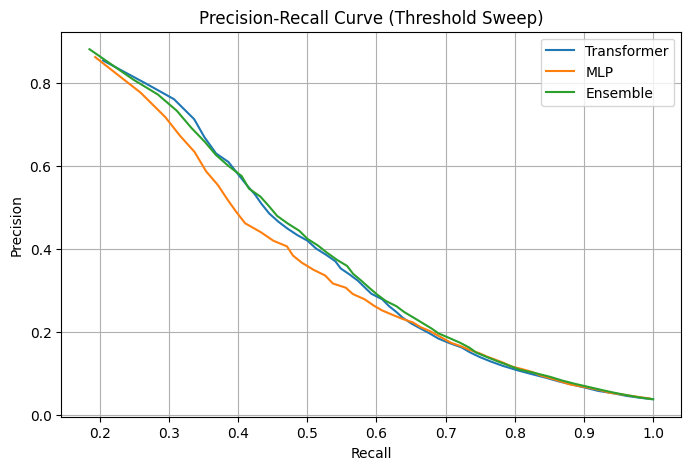

In [ ]:
# Run threshold sweep
def threshold_sweep(pred_dict, thresholds=np.linspace(0.01, 0.99, 50)):
    y_true = pred_dict["labels"]
    logits = pred_dict["logits"]

    probs = 1 / (1 + np.exp(-logits))

    results = []

    for t in thresholds:
        preds = (probs >= t).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, preds, average="binary", zero_division=0
        )

        f2 = fbeta_score(
            y_true, preds, beta=2.0, average="binary", zero_division=0
        )

        results.append({
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2
        })

    return results

def threshold_sweep_ensemble(
    pred_dict_mlp,
    pred_dict_trans,
    alpha=0.7,
    thresholds=np.linspace(0.01, 0.99, 50),
    blend_mode="prob",
):
    y_true = pred_dict_mlp["labels"]
    logits_mlp = pred_dict_mlp["logits"]
    logits_trans = pred_dict_trans["logits"]

    if blend_mode == "prob":
        probs_mlp = 1 / (1 + np.exp(-logits_mlp))
        probs_trans = 1 / (1 + np.exp(-logits_trans))
        probs = alpha * probs_trans + (1 - alpha) * probs_mlp

    elif blend_mode == "logit":
        blended_logits = alpha * logits_trans + (1 - alpha) * logits_mlp
        probs = 1 / (1 + np.exp(-blended_logits))

    else:
        raise ValueError(f"Unsupported blend_mode: {blend_mode}")

    results = []

    for t in thresholds:
        preds = (probs >= t).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, preds, average="binary", zero_division=0
        )

        f2 = fbeta_score(
            y_true, preds, beta=2.0, average="binary", zero_division=0
        )

        results.append({
            "alpha": float(alpha),
            "blend_mode": blend_mode,
            "threshold": float(t),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "f2": float(f2),
        })

    return results

def blend_weight_sweep(
    pred_dict_mlp,
    pred_dict_trans,
    alphas=np.linspace(0.0, 1.0, 11),
    thresholds=np.linspace(0.01, 0.99, 50),
    blend_mode="prob",
):
    all_results = []

    for alpha in alphas:
        sweep = threshold_sweep_ensemble(
            pred_dict_mlp=pred_dict_mlp,
            pred_dict_trans=pred_dict_trans,
            alpha=alpha,
            thresholds=thresholds,
            blend_mode=blend_mode,
        )
        all_results.extend(sweep)

    return all_results

def get_best_by_metric(sweep_results, metric="f2"):
    return max(sweep_results, key=lambda x: x[metric])


thresholds = np.linspace(0.01, 0.99, 100)
alphas = np.linspace(0.0, 1.0, 21)  # finer sweep: 0.00, 0.05, ..., 1.00

transformer_sweep = threshold_sweep(transformer_preds, thresholds=thresholds)
mlp_sweep = threshold_sweep(mlp_preds, thresholds=thresholds)

ensemble_prob_sweep = blend_weight_sweep(
    pred_dict_mlp=mlp_preds,
    pred_dict_trans=transformer_preds,
    alphas=alphas,
    thresholds=thresholds,
    blend_mode="prob",
)

ensemble_logit_sweep = blend_weight_sweep(
    pred_dict_mlp=mlp_preds,
    pred_dict_trans=transformer_preds,
    alphas=alphas,
    thresholds=thresholds,
    blend_mode="logit",
)

best_transformer = get_best_by_metric(transformer_sweep, "f2")
best_mlp = get_best_by_metric(mlp_sweep, "f2")
best_ensemble_prob = get_best_by_metric(ensemble_prob_sweep, "f2")
best_ensemble_logit = get_best_by_metric(ensemble_logit_sweep, "f2")

print("Best Transformer:", best_transformer)
print("Best MLP:", best_mlp)
print("Best Ensemble (prob blend):", best_ensemble_prob)
print("Best Ensemble (logit blend):", best_ensemble_logit)


def plot_metric(sweep, label, metric="f2"):
    thresholds = [x["threshold"] for x in sweep]
    values = [x[metric] for x in sweep]
    plt.plot(thresholds, values, label=label)

plt.figure(figsize=(8,5))

plot_metric(transformer_sweep, "Transformer", "f2")
plot_metric(mlp_sweep, "MLP", "f2")
plot_metric(ensemble_prob_sweep, "Ensemble", "f2")

plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.title("F2 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    [x["recall"] for x in transformer_sweep],
    [x["precision"] for x in transformer_sweep],
    label="Transformer"
)

plt.plot(
    [x["recall"] for x in mlp_sweep],
    [x["precision"] for x in mlp_sweep],
    label="MLP"
)

plt.plot(
    [x["recall"] for x in ensemble_blend_sweep],
    [x["precision"] for x in ensemble_blend_sweep],
    label="Ensemble"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Threshold Sweep)")
plt.legend()
plt.grid(True)
plt.show()